In [1]:
import nltk
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

In [2]:
import wordcloud
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize,sent_tokenize
import re
import spacy
nlp=spacy.load('en_core_web_sm')

In [7]:
df=pd.read_csv('/content/amazonreviews.tsv',sep='\t')
df

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."
...,...,...
9995,pos,A revelation of life in small town America in ...
9996,pos,Great biography of a very interesting journali...
9997,neg,Interesting Subject; Poor Presentation: You'd ...
9998,neg,Don't buy: The box looked used and it is obvio...


In [8]:
df.shape

(10000, 2)

In [9]:
df.size

20000

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [11]:
df.isnull().sum()

,0
label,0
review,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df=df.dropna(subset=['review'])

In [14]:
df=df.reset_index(drop=True)

In [15]:
print("Shape after cleaning:",df.shape)

Shape after cleaning: (10000, 2)


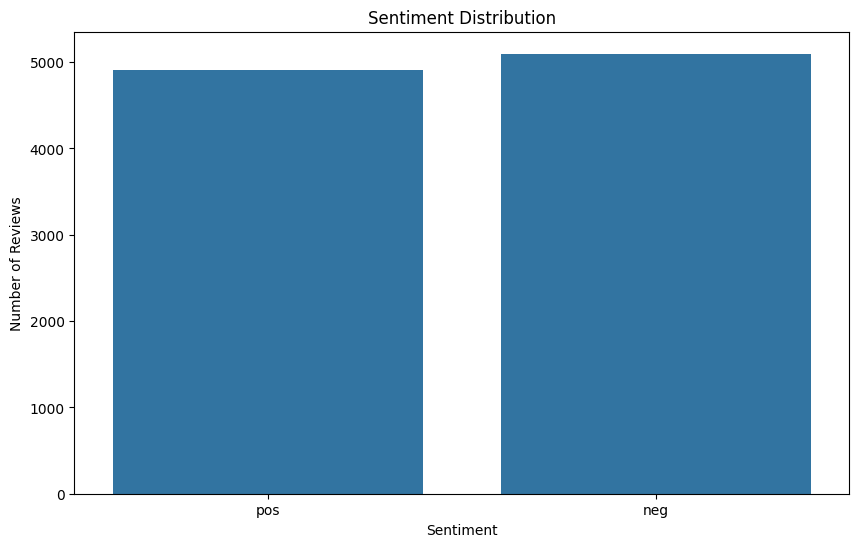

In [50]:
#Sentiment Distribution
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='label')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

In [17]:
df['sentiment']=df['label'].map({
    'neg':0,
    'pos':1})
print(df[['label','sentiment']].head())

  label  sentiment
0   pos          1
1   pos          1
2   pos          1
3   pos          1
4   pos          1


In [18]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def nlp_pipeline(text):
    text = text.lower()
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    text = " ".join(tokens)
    return text

In [20]:
from bs4 import BeautifulSoup
df['cleaned_review'] = df['review'].apply(nlp_pipeline)
print(df[['review', 'cleaned_review']].head())

                                              review  \
0  Stuning even for the non-gamer: This sound tra...   
1  The best soundtrack ever to anything.: I'm rea...   
2  Amazing!: This soundtrack is my favorite music...   
3  Excellent Soundtrack: I truly like this soundt...   
4  Remember, Pull Your Jaw Off The Floor After He...   

                                      cleaned_review  
0  stuning even nongamer sound track beautiful pa...  
1  best soundtrack ever anything im reading lot r...  
2  amazing soundtrack favorite music time hand in...  
3  excellent soundtrack truly like soundtrack enj...  
4  remember pull jaw floor hearing youve played g...  


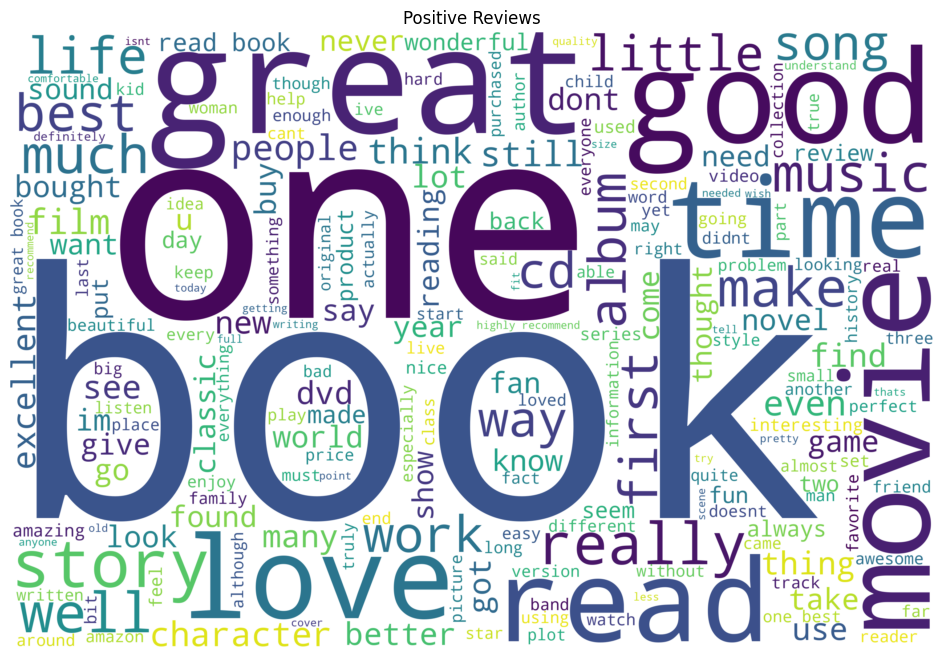

In [21]:
#Word cloud for positive reviews

positive_texxt=" ".join(
    df[df['label']=='pos']['cleaned_review']
)
wordcloud_pos=wordcloud.WordCloud(
    width=3000,
    height=2000,
    background_color='white'
).generate(positive_texxt)
plt.figure(figsize=(16,8))
plt.imshow(wordcloud_pos,interpolation='bilinear')
plt.axis('off')
plt.title('Positive Reviews')
plt.show()

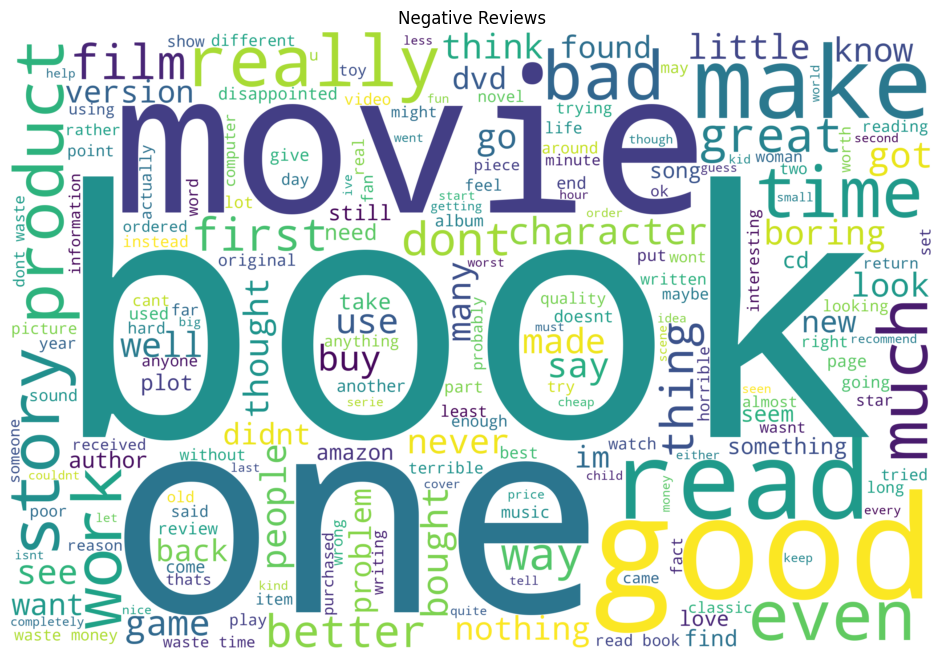

In [22]:
#Word cloud for negative reviews

positive_texxt=" ".join(
    df[df['label']=='neg']['cleaned_review']
)
wordcloud_pos=wordcloud.WordCloud(
    width=3000,
    height=2000,
    background_color='white'
).generate(positive_texxt)
plt.figure(figsize=(16,8))
plt.imshow(wordcloud_pos,interpolation='bilinear')
plt.axis('off')
plt.title('Negative Reviews')
plt.show()

In [24]:
#most common words
from collections import Counter
all_words=" ".join(df['cleaned_review']).split()
word_counts=Counter(all_words)
common_words=word_counts.most_common(20)
print(common_words)

[('book', 7544), ('one', 4054), ('movie', 3027), ('like', 2890), ('read', 2812), ('good', 2774), ('great', 2722), ('time', 2408), ('would', 2381), ('get', 2220), ('dont', 1770), ('story', 1612), ('really', 1605), ('make', 1466), ('first', 1444), ('work', 1440), ('much', 1418), ('even', 1400), ('well', 1372), ('love', 1354)]


In [26]:
#Feature Selection
x=df['cleaned_review']
y=df['sentiment']

In [28]:
#Train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=80)

In [29]:
#TF-IDF feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)
x_train_tfidf=tfidf.fit_transform(x_train)
x_test_tfidf=tfidf.transform(x_test)
print("Shape of X_train_tfidf:",x_train_tfidf.shape)
print("Shape of X_test_tfidf:",x_test_tfidf.shape)

Shape of X_train_tfidf: (7000, 10000)
Shape of X_test_tfidf: (3000, 10000)


In [30]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
lr=LogisticRegression(
    max_iter=1000,
    random_state=50
)
lr.fit(x_train_tfidf,y_train)
y_pred_lr=lr.predict(x_test_tfidf)
print("Accuracy Score:",accuracy_score(y_test,y_pred_lr))
print("Classification Report:\n",classification_report(y_test,y_pred_lr))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_lr))

Accuracy Score: 0.8553333333333333
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86      1556
           1       0.85      0.85      0.85      1444

    accuracy                           0.86      3000
   macro avg       0.86      0.85      0.86      3000
weighted avg       0.86      0.86      0.86      3000

Confusion Matrix:
 [[1345  211]
 [ 223 1221]]


In [31]:
y_pred_lr=lr.predict(x_test_tfidf)
print(y_pred_lr)

[0 1 0 ... 1 0 0]


In [33]:
from sklearn.metrics import accuracy_score,f1_score
accuracy_lr=accuracy_score(y_test,y_pred_lr)
print("Accuracy Score is:",accuracy_lr)
f1_lr=f1_score(y_test,y_pred_lr)
print("F1 Score is:",f1_lr)

Accuracy Score is: 0.8553333333333333
F1 Score is: 0.849095966620306


In [34]:
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=['Negative', 'Positive']
    )
)

              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86      1556
    Positive       0.85      0.85      0.85      1444

    accuracy                           0.86      3000
   macro avg       0.86      0.85      0.86      3000
weighted avg       0.86      0.86      0.86      3000



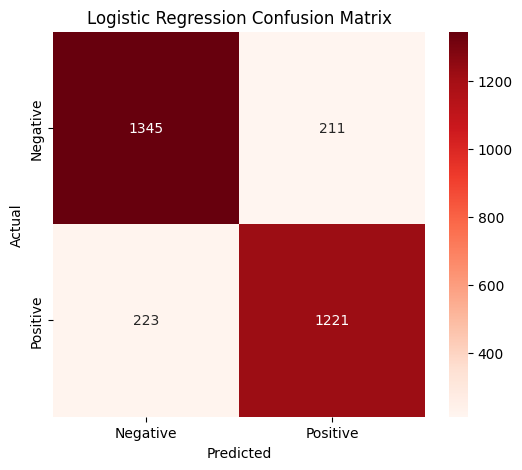

In [37]:
cm_lr= confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [38]:
#SVM
from sklearn.svm import SVC
svm=SVC(random_state=50)
svm.fit(x_train_tfidf,y_train)
y_pred_svm=svm.predict(x_test_tfidf)
accuracy_svm=accuracy_score(y_test,y_pred_svm)
print("Accuracy Score:",accuracy_svm)
f1_svm=f1_score(y_test,y_pred_svm)
print("F1 Score:",f1_svm)
print("Classification Report:\n",classification_report(y_test,y_pred_svm))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_svm))

Accuracy Score: 0.858
F1 Score: 0.8530020703933747
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.86      0.86      1556
           1       0.85      0.86      0.85      1444

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000

Confusion Matrix:
 [[1338  218]
 [ 208 1236]]


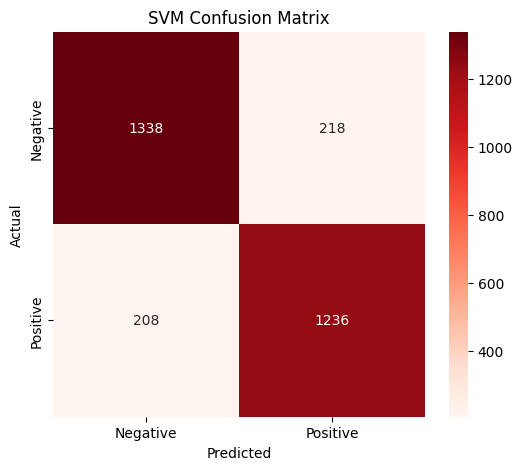

In [39]:
cm_svm= confusion_matrix(
    y_test,
    y_pred_svm)
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

In [40]:
#Comparsion
models_results=pd.DataFrame({
    'model':[
        'Logistic Regression',
        'SVM'
    ],
    'accuracy':[
        accuracy_lr,
        accuracy_svm
    ],
    'f1_score':[
        f1_lr,
        f1_svm
    ]
})
print(models_results)

                 model  accuracy  f1_score
0  Logistic Regression  0.855333  0.849096
1                  SVM  0.858000  0.853002


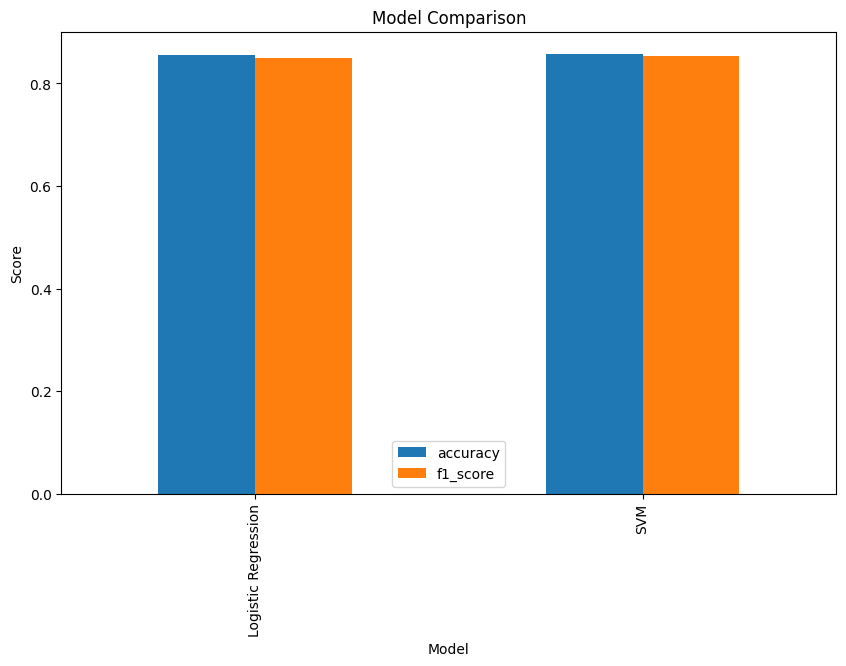

In [41]:
models_results.set_index('model')[['accuracy','f1_score']].plot(
    kind='bar',
    figsize=(10,6)
)
plt.title('Model Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.show()

In [42]:
from sklearn.model_selection import cross_val_score
#CV for lr
cv=cross_val_score(
    lr,
    x_train_tfidf,
    y_train,
    cv=5,
    scoring='accuracy'
)
print("Cross Validation Scores:",cv)
print("Mean Accuracy:",cv.mean())

Cross Validation Scores: [0.85785714 0.845      0.85071429 0.85       0.85214286]
Mean Accuracy: 0.8511428571428572


In [43]:
#CV for svm
cv=cross_val_score(
    svm,
    x_train_tfidf,
    y_train,
    cv=5,
    scoring='accuracy'
)
print("Cross Validation Scores:",cv)
print("Mean Accuracy:",cv.mean())

Cross Validation Scores: [0.86       0.84714286 0.85714286 0.85642857 0.85214286]
Mean Accuracy: 0.8545714285714286


In [44]:
#Own review
new_rev=["This product is absolutely amazing. I really love it."]
new_rev_tfidf=tfidf.transform(new_rev)
pred=lr.predict(new_rev_tfidf)
if pred[0]==0:
    print("Negative Review")
else:
    print("Positive Review")

Positive Review


In [49]:
#Complete prdiction function

def predict_sentiment(review):
    # Preprocess
    cleaned = nlp_pipeline(review)
    # TF-IDF
    vector = tfidf.transform([cleaned])
    # Prediction
    prediction = lr.predict(vector)[0]
    if prediction == 1:
        return "Positive"
    else:
        return "Negative"

review=input("Enter your review:")
predict_sentiment(review)

Enter your review:The spiderman movie is good.


'Positive'